In [17]:
import json
import os

def import_from_ipynb(notebook_name):
    """Import all code from a .ipynb file"""
    try:
        with open(f'./{notebook_name}.ipynb', 'r', encoding='utf-8') as f:
            notebook = json.load(f)
        
        # Combine all code cells - FIXED: Handle list format
        all_code = ""
        for cell in notebook['cells']:
            if cell['cell_type'] == 'code':
                # Handle both string and list formats
                cell_source = cell['source']
                if isinstance(cell_source, list):
                    # If it's a list, join the lines
                    all_code += ''.join(cell_source) + "\n\n"
                else:
                    # If it's already a string
                    all_code += cell_source + "\n\n"
        
        # Execute the code
        exec(all_code, globals())
        print(f"✅ Imported {notebook_name}.ipynb")
        return True
        
    except Exception as e:
        print(f"❌ Failed to import {notebook_name}.ipynb: {e}")
        return False

# Import all your notebook files
import_from_ipynb("preprocessing")
import_from_ipynb("exploration")
import_from_ipynb("training")
import_from_ipynb("evaluation")

print("🎉 All functions are now available in this notebook!")

✅ Imported preprocessing.ipynb
✅ Imported exploration.ipynb
✅ Imported training.ipynb
✅ Imported evaluation.ipynb
🎉 All functions are now available in this notebook!


In [18]:
# Parameters
sequence_length = 30
file_path = r"C:\Desktop\DL_ASSIGMENT\data\BAJAJ-AUTO.csv"

In [19]:
# Step 1: Load and preprocess data
X_train, X_test, y_train, y_test, scaler_X, scaler_y, data = load_and_preprocess_data(
    file_path, sequence_length=sequence_length
)
print("X_train shape:", X_train.shape)

X_train shape: (1940, 30, 3)



📄 Columns in dataset:
Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

📈 Basic Statistics:
        Prev Close         Open         High          Low         Last  \
count  2456.000000  2456.000000  2456.000000  2456.000000  2456.000000   
mean   2465.300285  2467.863986  2497.442447  2436.705680  2466.142121   
std     573.472714   574.785879   579.582009   569.392706   573.692469   
min    1311.800000  1320.000000  1329.000000  1295.000000  1322.000000   
25%    1978.737500  1980.450000  2009.000000  1953.800000  1979.500000   
50%    2536.375000  2535.125000  2569.500000  2500.700000  2536.100000   
75%    2874.150000  2880.000000  2910.000000  2848.450000  2875.162500   
max    4237.450000  4260.000000  4361.400000  4200.000000  4236.000000   

             Close         VWAP        Volume      Turnover         Trades  \
count  2

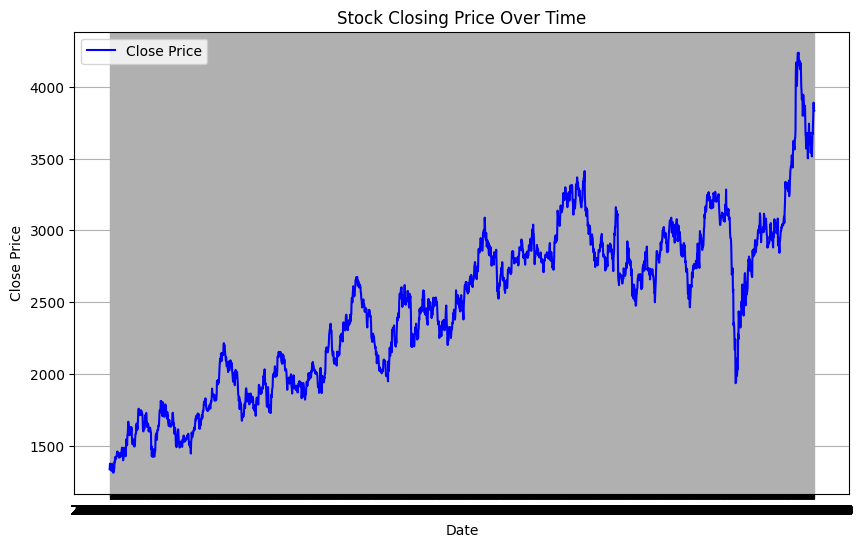

In [20]:
# Step 2: Explore data
explore_data(data)

In [21]:
# Step 3: Build and train GRU model
model = build_gru_model((X_train.shape[1], X_train.shape[2]))
model, history = train_model(model, X_train, y_train, X_test, y_test)

c:\Desktop\DL_ASSIGMENT\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 50)         │         8,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,601 (92.19 KB)

 Trainable params: 23,601 (92.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.0118 - val_loss: 0.0012
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0018 - val_loss: 9.7160e-04
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0015 - val_loss: 0.0010
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0013 - val_loss: 9.0411e-04
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0013 - val_loss: 9.9728e-04
Epoch 12/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step

📈 Model Evaluation Results:
MSE  : 5091.618
MAE  : 52.442
R²   : 0.972


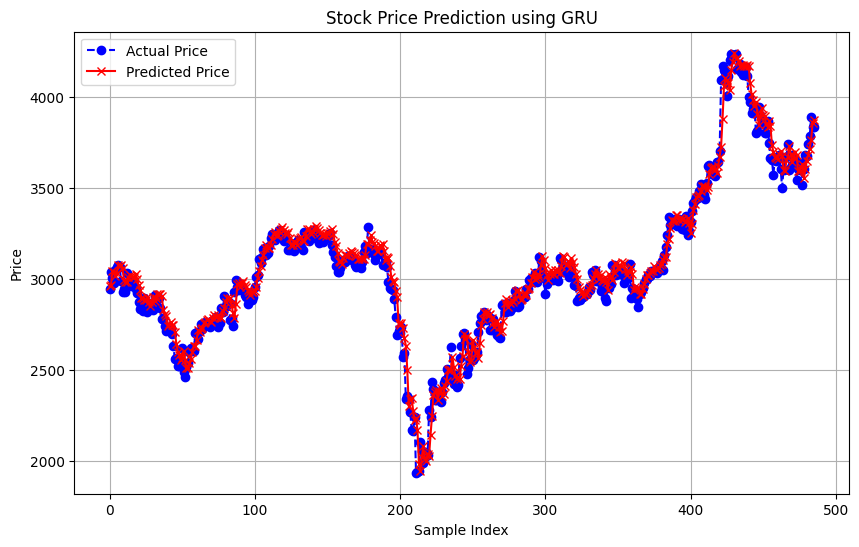

In [22]:
# Step 4: Evaluate and visualize
y_pred, y_test_actual, mse, mae, r2 = evaluate_model(model, X_test, y_test, scaler_y)
visualize_results(y_test_actual, y_pred)

In [23]:
# Step 5: Predict next day price
last_sequence = scaler_X.transform(data[['Open', 'High', 'Low']].values)[-sequence_length:]
predict_next_day(model, last_sequence, scaler_y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

💰 Predicted Next Day Close Price: 3861.94


np.float32(3861.9397)